In [0]:
# for colab
%tensorflow_version 2.x
from __future__ import absolute_import, division, print_function, unicode_literals
import os
import tensorflow as tf
import numpy as np
from tensorflow import keras
import time

from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

In [0]:
if tf.test.is_gpu_available():
    print(tf.test.gpu_device_name())
else:
    print("TF cannot find GPU")
tf.__version__  # make sure it's 2.0!



# With keras

In [0]:
path_to_file = tf.keras.utils.get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')

In [0]:
# Read, then decode for py2 compat.
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')
# length of text is the number of characters in it
print ('Length of text: {} characters'.format(len(text)))

In [0]:
# Take a look at the first 250 characters in text
print(text[0:250])

In [0]:
# The unique characters in the file
vocab = sorted(set(text))
print ('{} unique characters'.format(len(vocab)))

In [0]:
# Creating a mapping from unique characters to indices
# Mapping strings to a numerical representation with 2 lookup tables (char to num + num to char)
char2idx = {u:i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[c] for c in text])

In [0]:
#chars a mapped from 0 to map length
print('{')
for char,_ in zip(char2idx, range(len(vocab))):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')

In [0]:
# Show how the first 13 characters from the text are mapped to integers
print ('{} ---- characters mapped to int ---- > {}'.format(repr(text[:13]), text_as_int[:13]))

In [0]:
# Dividing our text into sequences, f.e. for seq.length = 4 Hello-> input=Hell, output = ello
# The maximum length sentence we want for a single input in characters
seq_length = 100
examples_per_epoch = len(text)//(seq_length+1)

# Create training examples / targets
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

for i in char_dataset.take(5):
  print(idx2char[i.numpy()])

In [0]:
#batching the sequences 
sequences = char_dataset.batch(seq_length+1, drop_remainder=True)

for item in sequences.take(5):
  print(repr(''.join(idx2char[item.numpy()])))

In [0]:
#mapping our sequences
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

In [0]:
#looks like this
for input_example, target_example in  dataset.take(1):
  print ('Input data: ', repr(''.join(idx2char[input_example.numpy()])))
  print ('Target data:', repr(''.join(idx2char[target_example.numpy()])))

In [0]:
for i, (input_idx, target_idx) in enumerate(zip(input_example[:5], target_example[:5])):
    print("Step {:4d}".format(i))
    print("  input: {} ({:s})".format(input_idx, repr(idx2char[input_idx])))
    print("  expected output: {} ({:s})".format(target_idx, repr(idx2char[target_idx])))

# Functions for building the model and the text-output

In [0]:
# Batch size
BATCH_SIZE = 64

# Buffer size to shuffle the dataset
# (TF data is designed to work with possibly infinite sequences,
# so it doesn't attempt to shuffle the entire sequence in memory. Instead,
# it maintains a buffer in which it shuffles elements).
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

dataset

In [0]:
# Length of the vocabulary in chars
vocab_size = len(vocab)

# The embedding dimension
embedding_dim = 256

# Number of RNN units
rnn_units = 1024

In [0]:
#super easy with keras layers
def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, embedding_dim,
                                  batch_input_shape=[batch_size, None]),
        tf.keras.layers.GRU(rnn_units, #LSTM would be possible too
                            return_sequences=True,
                            stateful=True,
                            recurrent_initializer='glorot_uniform'),
        tf.keras.layers.Dense(vocab_size)
    ])
    return model

In [0]:
# used with the generate_text function to load the predefined model+weights into the text generator
def model_loader(): 
  tf.train.latest_checkpoint(checkpoint_dir)
  model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)
  model.load_weights(tf.train.latest_checkpoint(checkpoint_dir))
  model.build(tf.TensorShape([1, None]))
  model.summary()
  return model

In [0]:
def generate_text(model, temp, start_string):
  # Evaluation step (generating text using the learned model)

  # Number of characters to generate
  num_generate = 2000

  # Converting our start string to numbers (vectorizing)
  input_eval = [char2idx[s] for s in start_string]
  input_eval = tf.expand_dims(input_eval, 0)

  # Empty string to store our results
  text_generated = []

  # Low temperatures results in more predictable text.
  # Higher temperatures results in more surprising text.
  # Experiment to find the best setting.
  temperature = temp

  # Here batch size == 1
  model.reset_states()
  for i in range(num_generate):
      predictions = model(input_eval)
      # remove the batch dimension
      predictions = tf.squeeze(predictions, 0)

      # using a categorical distribution to predict the word returned by the model
      predictions = predictions / temperature
      predicted_id = tf.random.categorical(predictions, num_samples=1)[-1,0].numpy()

      # We pass the predicted word as the next input to the model
      # along with the previous hidden state
      input_eval = tf.expand_dims([predicted_id], 0)

      text_generated.append(idx2char[predicted_id])

  return (start_string + ''.join(text_generated))

# Keras training loop

In [0]:
model = build_model(
  vocab_size = len(vocab),
  embedding_dim=embedding_dim,
  rnn_units=rnn_units,
  batch_size=BATCH_SIZE)

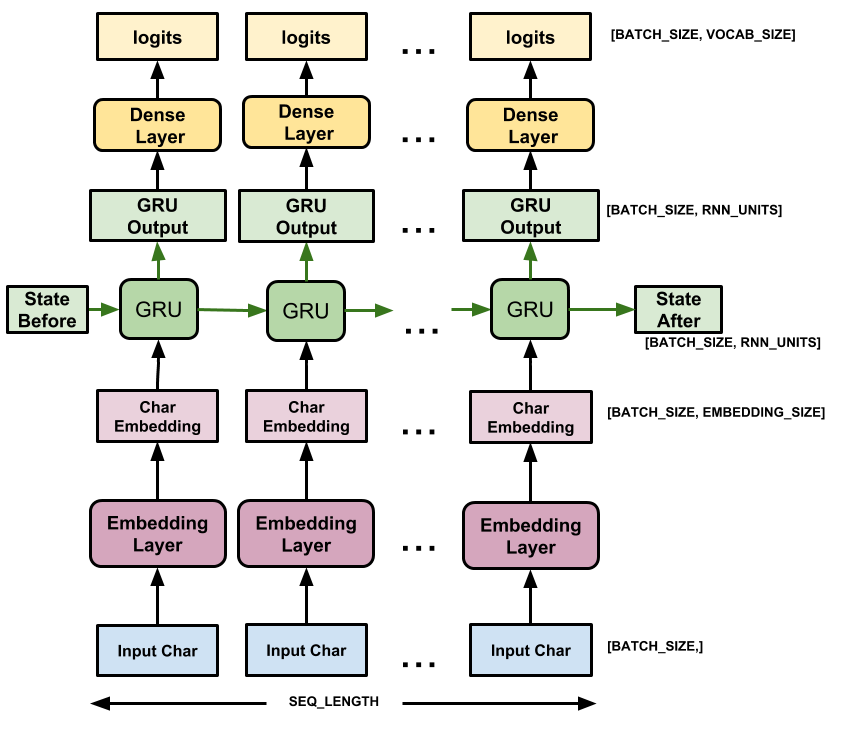

In [0]:
for input_example_batch, target_example_batch in dataset.take(1):
    example_batch_predictions = model(input_example_batch)
    print(example_batch_predictions.shape, "# (batch_size, sequence_length, vocab_size)")

In [0]:
model.summary()

In [0]:
sampled_indices = tf.random.categorical(example_batch_predictions[0], num_samples=1)
sampled_indices = tf.squeeze(sampled_indices,axis=-1).numpy()

In [0]:
sampled_indices

In [0]:
print("Input: \n", repr("".join(idx2char[input_example_batch[0]])))
print()
print("Next Char Predictions: \n", repr("".join(idx2char[sampled_indices ])))

In [0]:
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

example_batch_loss  = loss(target_example_batch, example_batch_predictions)
print("Prediction shape: ", example_batch_predictions.shape, " # (batch_size, sequence_length, vocab_size)")
print("scalar_loss:      ", example_batch_loss.numpy().mean())

In [0]:
model.compile(optimizer='adam', loss=loss)

In [0]:
# Directory where the checkpoints will be saved
checkpoint_dir = './training_checkpoints'
# Name of the checkpoint files
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}")

checkpoint_callback=tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True)

In [0]:
EPOCHS=10
history = model.fit(dataset, epochs=EPOCHS, callbacks=[checkpoint_callback])

In [0]:
print(generate_text(model_loader(),0.9, start_string=u"Ravi: ")) #temperature makes output more or less random

# Gradient Tape

In [0]:
model = build_model(
  vocab_size = len(vocab),
  embedding_dim=embedding_dim,
  rnn_units=rnn_units,
  batch_size=BATCH_SIZE)

In [0]:
optimizer = tf.keras.optimizers.Adam()

In [0]:
@tf.function
def train_step(inp, target):
  with tf.GradientTape() as tape:
    predictions = model(inp)
    loss = tf.reduce_mean(
        tf.keras.losses.sparse_categorical_crossentropy(
            target, predictions, from_logits=True))
  grads = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(grads, model.trainable_variables))

  return loss

In [0]:
# Training step
EPOCHS = 10

for epoch in range(EPOCHS):
  start = time.time()

  # initializing the hidden state at the start of every epoch
  # initally hidden is None
  hidden = model.reset_states()

  for (batch_n, (inp, target)) in enumerate(dataset):
    loss = train_step(inp, target)

    if batch_n % 100 == 0:
      template = 'Epoch {} Batch {} Loss {}'
      print(template.format(epoch+1, batch_n, loss))

  # saving (checkpoint) the model every 5 epochs
  if (epoch + 1) % 5 == 0:
    model.save_weights(checkpoint_prefix.format(epoch=epoch))

  print ('Epoch {} Loss {:.4f}'.format(epoch+1, loss))
  print ('Time taken for 1 epoch {} sec\n'.format(time.time() - start))

model.save_weights(checkpoint_prefix.format(epoch=epoch))

In [0]:
print(generate_text(model_loader(), 0.9, start_string=u"Kartik: "))

# Own GRU layer

In [0]:
class GRU:
    """Implementation of a Gated Recurrent Unit (GRU) as described in [1].
    
    [1] Chung, J., Gulcehre, C., Cho, K., & Bengio, Y. (2014). Empirical evaluation of gated recurrent neural networks on sequence modeling. arXiv preprint arXiv:1412.3555. Titel anhand dieser ArXiv-ID in Citavi-Projekt übernehmen
    
    Arguments
    ---------
    input_dimensions: int
        The size of the input vectors (x_t).
    hidden_size: int
        The size of the hidden layer vectors (h_t).
    dtype: obj
        The datatype used for the variables and constants (optional).
    """
    
    def __init__(self, input_dimensions, hidden_size, dtype=tf.float64):
        self.input_dimensions = input_dimensions
        self.hidden_size = hidden_size
        
        # Weights for input vectors of shape (input_dimensions, hidden_size)
        self.Wr = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.input_dimensions, self.hidden_size), mean=0, stddev=0.01), name='Wr')
        self.Wz = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.input_dimensions, self.hidden_size), mean=0, stddev=0.01), name='Wz')
        self.Wh = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.input_dimensions, self.hidden_size), mean=0, stddev=0.01), name='Wh')
        
        # Weights for hidden vectors of shape (hidden_size, hidden_size)
        self.Ur = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.hidden_size, self.hidden_size), mean=0, stddev=0.01), name='Ur')
        self.Uz = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.hidden_size, self.hidden_size), mean=0, stddev=0.01), name='Uz')
        self.Uh = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.hidden_size, self.hidden_size), mean=0, stddev=0.01), name='Uh')
        
        # Biases for hidden vectors of shape (hidden_size,)
        self.br = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.hidden_size,), mean=0, stddev=0.01), name='br')
        self.bz = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.hidden_size,), mean=0, stddev=0.01), name='bz')
        self.bh = tf.Variable(tf.random.truncated_normal(dtype=dtype, shape=(self.hidden_size,), mean=0, stddev=0.01), name='bh')
               
        # Put the time-dimension upfront for the scan operator
        self.x_t = tf.transpose([1, 0, 2], name='x_t')
        
        # A little hack (to obtain the same shape as the input matrix) to define the initial hidden state h_0
        self.h_0 = tf.matmul(self.x_t[0, :, :], tf.zeros(dtype=tf.float64, shape=(input_dimensions, hidden_size)), name='h_0')
        
        # Perform the scan operator
        self.h_t_transposed = tf.scan(self.forward_pass, self.x_t, initializer=self.h_0, name='h_t_transposed')
        
        # Transpose the result back
        self.h_t = tf.transpose(self.h_t_transposed, [1, 0, 2], name='h_t')

    def forward_pass(self, h_tm1, x_t):
        """Perform a forward pass.
        
        Arguments
        ---------
        h_tm1: np.matrix
            The hidden state at the previous timestep (h_{t-1}).
        x_t: np.matrix
            The input vector.
        """
        # Definitions of z_t and r_t
        z_t = tf.sigmoid(tf.matmul(x_t, self.Wz) + tf.matmul(h_tm1, self.Uz) + self.bz)
        r_t = tf.sigmoid(tf.matmul(x_t, self.Wr) + tf.matmul(h_tm1, self.Ur) + self.br)
        
        # Definition of h~_t
        h_proposal = tf.tanh(tf.matmul(x_t, self.Wh) + tf.matmul(tf.multiply(r_t, h_tm1), self.Uh) + self.bh)
        
        # Compute the next hidden state
        h_t = tf.multiply(1 - z_t, h_tm1) + tf.multiply(z_t, h_proposal)
        
        return h_t
    
#%% (3) Initialize and train the model.

# The input has 2 dimensions: dimension 0 is reserved for the first term and dimension 1 is reverved for the second term
input_dimensions = 2

# Arbitrary number for the size of the hidden state
hidden_size = 16

# Initialize a session
session = tf.compat.v1.Session()


In [0]:
# Create a new instance of the GRU model
gru = GRU(input_dimensions, hidden_size)

In [0]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

from tensorflow import initializers
from tensorflow.keras import regularizers
from tensorflow.keras import constraints
from keras.legacy import interfaces
from tensorflow.keras.layers import Layer
from keras.utils.generic_utils import to_list


class Embedding(Layer):
    """Turns positive integers (indexes) into dense vectors of fixed size.
    eg. [[4], [20]] -> [[0.25, 0.1], [0.6, -0.2]]
    This layer can only be used as the first layer in a model.
    # Example
    ```python
      model = Sequential()
      model.add(Embedding(1000, 64, input_length=10))
      # the model will take as input an integer matrix of size (batch, input_length).
      # the largest integer (i.e. word index) in the input should be
      # no larger than 999 (vocabulary size).
      # now model.output_shape == (None, 10, 64), where None is the batch dimension.
      input_array = np.random.randint(1000, size=(32, 10))
      model.compile('rmsprop', 'mse')
      output_array = model.predict(input_array)
      assert output_array.shape == (32, 10, 64)
    ```
    # Arguments
        input_dim: int > 0. Size of the vocabulary,
            i.e. maximum integer index + 1.
        output_dim: int >= 0. Dimension of the dense embedding.
        embeddings_initializer: Initializer for the `embeddings` matrix
            (see [initializers](../initializers.md)).
        embeddings_regularizer: Regularizer function applied to
            the `embeddings` matrix
            (see [regularizer](../regularizers.md)).
        activity_regularizer: Regularizer function applied to
            the output of the layer (its "activation").
            (see [regularizer](../regularizers.md)).
        embeddings_constraint: Constraint function applied to
            the `embeddings` matrix
            (see [constraints](../constraints.md)).
        mask_zero: Whether or not the input value 0 is a special "padding"
            value that should be masked out.
            This is useful when using [recurrent layers](recurrent.md)
            which may take variable length input.
            If this is `True` then all subsequent layers
            in the model need to support masking or an exception will be raised.
            If mask_zero is set to True, as a consequence, index 0 cannot be
            used in the vocabulary (input_dim should equal size of
            vocabulary + 1).
        input_length: Length of input sequences, when it is constant.
            This argument is required if you are going to connect
            `Flatten` then `Dense` layers upstream
            (without it, the shape of the dense outputs cannot be computed).
    # Input shape
        2D tensor with shape: `(batch_size, sequence_length)`.
    # Output shape
        3D tensor with shape: `(batch_size, sequence_length, output_dim)`.
    # References
        - [A Theoretically Grounded Application of Dropout in
           Recurrent Neural Networks](http://arxiv.org/abs/1512.05287)
    """

    @interfaces.legacy_embedding_support
    def __init__(self, input_dim, output_dim,
                 embeddings_initializer='uniform',
                 embeddings_regularizer=None,
                 activity_regularizer=None,
                 embeddings_constraint=None,
                 mask_zero=False,
                 input_length=None,
                 **kwargs):
        if 'input_shape' not in kwargs:
            if input_length:
                kwargs['input_shape'] = (input_length,)
            else:
                kwargs['input_shape'] = (None,)
        super(Embedding, self).__init__(**kwargs)

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.embeddings_initializer = initializers.get(embeddings_initializer)
        self.embeddings_regularizer = regularizers.get(embeddings_regularizer)
        self.activity_regularizer = regularizers.get(activity_regularizer)
        self.embeddings_constraint = constraints.get(embeddings_constraint)
        self.mask_zero = mask_zero
        self.supports_masking = mask_zero
        self.input_length = input_length

    def build(self, input_shape):
        self.embeddings = self.add_weight(
            shape=(self.input_dim, self.output_dim),
            initializer=self.embeddings_initializer,
            name='embeddings',
            regularizer=self.embeddings_regularizer,
            constraint=self.embeddings_constraint,
            dtype=self.dtype)
        self.built = True

    def compute_mask(self, inputs, mask=None):
        if not self.mask_zero:
            return None
        output_mask = K.not_equal(inputs, 0)
        return output_mask

    def compute_output_shape(self, input_shape):
        if self.input_length is None:
            return input_shape + (self.output_dim,)
        else:
            # input_length can be tuple if input is 3D or higher
            in_lens = to_list(self.input_length, allow_tuple=True)
            if len(in_lens) != len(input_shape) - 1:
                raise ValueError(
                    '"input_length" is %s, but received input has shape %s' %
                    (str(self.input_length), str(input_shape)))
            else:
                for i, (s1, s2) in enumerate(zip(in_lens, input_shape[1:])):
                    if s1 is not None and s2 is not None and s1 != s2:
                        raise ValueError(
                            '"input_length" is %s, but received input has shape %s' %
                            (str(self.input_length), str(input_shape)))
                    elif s1 is None:
                        in_lens[i] = s2
            return (input_shape[0],) + tuple(in_lens) + (self.output_dim,)

    def call(self, inputs):
        if tf.keras.dtype(inputs) != 'int32':
            inputs = tf.keras.cast(inputs, 'int32')
        out = tf.keras.gather(self.embeddings, inputs)
        return out

    def get_config(self):
        config = {'input_dim': self.input_dim,
                  'output_dim': self.output_dim,
                  'embeddings_initializer':
                      initializers.serialize(self.embeddings_initializer),
                  'embeddings_regularizer':
                      regularizers.serialize(self.embeddings_regularizer),
                  'activity_regularizer':
                      regularizers.serialize(self.activity_regularizer),
                  'embeddings_constraint':
                      constraints.serialize(self.embeddings_constraint),
                  'mask_zero': self.mask_zero,
                  'input_length': self.input_length}
        base_config = super(Embedding, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))